# Clasificación con Machine Learning: comparación de modelos

En este notebook vamos a construir varios modelos de **Machine Learning para un problema de clasificación**.

El objetivo será predecir el salario de una persona (`salary`) utilizando diferentes características demográficas y laborales del dataset **Adult Income**.

El flujo de trabajo que seguiremos será el habitual en un proyecto de Machine Learning:

1. Carga de librerías
2. Carga y exploración del dataset
3. Limpieza de datos
4. Transformación de variables
5. Definición de variables de entrada y salida
6. Entrenamiento de varios modelos
7. Comparación de resultados

De esta forma podremos ver **qué modelo funciona mejor para este problema**.

El conjunto con el que entrenamos (ajustamos, 'fit') el modelo es el conjunto 'train' (entrenamiento). (La mayor parte de los datos, 60%).

Con el conjunto de train entrenamos 3 modelos: un decision tree, un random forest y un gradient boosting.


El conjunto con el que ajustamos los hiperparámetros del modelo (condiciones iniciales, parámetros del modelo) es el conjunto 'validation' (validación).

Sobre el conjunto de validación, evaluamos los modelos y nos quedamos con el modelo que tenga mejor precisión (ajustada/equilibrada).


El conjunto con el que comprobamos el aptitud del modelo es el conjunto 'test' o de prueba.

En el sentido estadístico (el más cercano al caso real), el resultado (precisión/la métrica que sea) más justo/real es el que obtenemos sobre el conjunto de test - porque nunca hemos evaluado el modelo sobre estos datos.



K-Fold Cross Validation

80% y 20%
Separamos los datos en conjuntos de train y test - pero hacemos esto K veces con una separación aleatoria distinta.

K divisiones distintas del conjunto original, cada una con su par (train, test).

Para cada división, aplicamos unos hiperparámetros distintos (alternativamente, si tenemos múltiples modelos en vez de hiperparámetros, aplicamos una división distinta para cada modelo). Al final hacemos una media del resultado en cada división y estimamos que la media (precisión) es el valor "real/final".

Basado en https://github.com/SaturdaysAI-Murcia/machine-learning

# <center> [Adult salaries](https://archive.ics.uci.edu/ml/datasets/adult): Gradient boosting
### <center>Predict whether income exceeds $50K/yr based on census data.

Link: https://www.kaggle.com/mattmet/income-prediction-xgboost-accuracy-86-02

**IMPORTANTE**

Utiliza el "Gradiente": El término "Gradient" se refiere a que el algoritmo emplea un algoritmo de descenso de gradiente para minimizar los errores (la función de pérdida) del conjunto de árboles que ya han sido entrenados

Básicamente, busca la ruta más eficiente para reducir el fallo en cada paso.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.ensemble      import ExtraTreesClassifier
from sklearn.ensemble      import GradientBoostingClassifier
from xgboost               import XGBClassifier, plot_tree

from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics         import accuracy_score, balanced_accuracy_score

# Leer CSV

In [ ]:
##### DOWNLOAD DATASET. ONLY IN COLAB !!!
!wget -P ./data/ https://raw.githubusercontent.com/SaturdaysAI-Murcia/machine-learning/master/data/adult.csv

--2026-03-12 17:20:51--  https://raw.githubusercontent.com/SaturdaysAI-Murcia/machine-learning/master/data/adult.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3818789 (3.6M) [text/plain]
Saving to: ‘./data/adult.csv’

adult.csv           100%[===================>]   3.64M  --.-KB/s    in 0.07s   

2026-03-12 17:20:51 (52.1 MB/s) - ‘./data/adult.csv’ saved [3818789/3818789]



In [ ]:
df = pd.read_csv("./data/adult.csv")

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,49,Private,101320,Assoc-acdm,12.0,Married-civ-spouse,NaN,Wife,White,Female,0,1902,40,United-States,>=50k
1,44,Private,236746,Masters,14.0,Divorced,Exec-managerial,Not-in-family,White,Male,10520,0,45,United-States,>=50k
2,38,Private,96185,HS-grad,NaN,Divorced,NaN,Unmarried,Black,Female,0,0,32,United-States,<50k
3,38,Self-emp-inc,112847,Prof-school,15.0,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,40,United-States,>=50k
4,42,Self-emp-not-inc,82297,7th-8th,NaN,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,50,United-States,<50k


# Qué queremos predecir? -> `df.salary`

## Variable objetivo

La variable que queremos predecir es **salary**.

En este gráfico observamos cuántos ejemplos hay de cada clase.

Esto es importante porque los modelos pueden verse afectados si las clases están **muy desbalanceadas**.

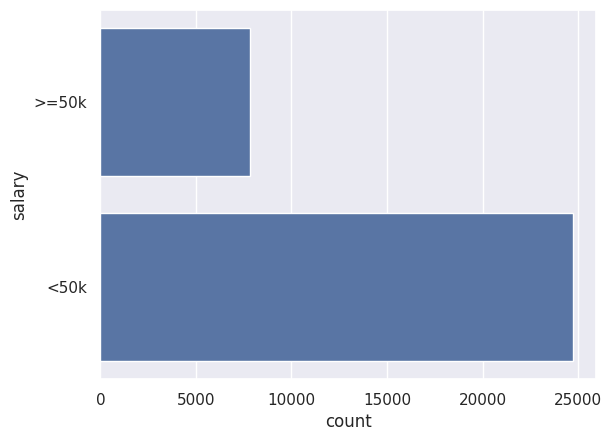

In [ ]:
sns.countplot(df.salary);

# Variables

## Identificación de variables categóricas y numéricas

En Machine Learning es importante distinguir entre:

- **variables numéricas**
- **variables categóricas**

Esto nos permitirá aplicar las transformaciones adecuadas a cada tipo de variable.

In [ ]:
cat  = df.select_dtypes(include=[object]).columns
num  = df.select_dtypes(exclude=[object, 'datetime64','timedelta64']).columns
time = df.select_dtypes(include=['datetime64']).columns

print("\nNumerical features:\n", num.values)
print("\nCategorical features:\n", cat.values)
print("\nDate/time features:\n", time.values)


Numerical features:
 ['age' 'fnlwgt' 'education-num' 'capital-gain' 'capital-loss'
 'hours-per-week']

Categorical features:
 ['workclass' 'education' 'marital-status' 'occupation' 'relationship'
 'race' 'sex' 'native-country' 'salary']

Date/time features:
 []


# Missings

In [ ]:
# Eliminamos las filas que contienen valores faltantes (NaN) en cualquier columna
# axis='rows' indica que la operación se aplica sobre las filas del DataFrame
# Es decir, si una fila tiene algún dato faltante, se elimina completamente
df = df.dropna(axis='rows')

# Categorical

## Transformación de variables categóricas

Los modelos de Machine Learning normalmente trabajan con **valores numéricos**.

Por ello convertimos las variables categóricas a números utilizando **Label Encoding**.

Esto asigna un número entero a cada categoría.

In [ ]:
df[cat] = df[cat].apply(LabelEncoder().fit_transform)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
1,44,4,236746,12,14.0,0,4,1,4,1,10520,0,45,39,1
3,38,5,112847,14,15.0,2,10,0,1,1,0,0,40,39,1
5,20,4,63210,11,9.0,4,6,3,4,1,0,0,15,39,0
8,46,4,328216,11,9.0,2,3,0,4,1,0,0,40,39,1
21,26,4,746432,11,9.0,4,6,3,2,1,0,0,48,39,0


# Models

## Definición de variables de entrada y salida

Ahora definimos:

- **X** → variables explicativas (features)
- **y** → variable objetivo (salary)

Estas serán las variables que utilizaremos para entrenar los modelos.

In [ ]:
x = df[['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'
       ]]
y = df["salary"]

## Entrenamiento y comparación de modelos

En esta sección entrenaremos varios algoritmos de clasificación, por ejemplo:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Después compararemos sus resultados para ver **qué modelo obtiene mejor rendimiento** en este problema.

In [ ]:
# Definimos una lista con los modelos de Machine Learning que queremos comparar.
# Cada elemento de la lista es una tupla con:
# (nombre_del_modelo, objeto_del_modelo)

models = [
    ('Logistic Regression', LogisticRegression(n_jobs=-1)),
    ('Decision Tree',       DecisionTreeClassifier()),
    ('Extra Trees',         ExtraTreesClassifier(n_jobs=-1)),
    ('Random Forest',       RandomForestClassifier(n_jobs=-1)),
    ('Gradient Boosting',   GradientBoostingClassifier()),
    ('XGBoost',             XGBClassifier(n_estimators=250))
]

# Listas donde almacenaremos los resultados de los modelos
outcome = []      # Guardará los resultados de las validaciones cruzadas
Modelnames = []   # Guardará los nombres de los modelos evaluados

for name, model in models:

    # Definimos una validación cruzada estratificada
    # n_splits=5 → el dataset se divide en 5 particiones
    # shuffle=True → mezcla los datos antes de dividirlos
    # random_state=0 → fija la semilla para reproducibilidad

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

    # Evaluamos el modelo usando validación cruzada
    # cross_val_score entrena y evalúa el modelo en cada partición
    # scoring='accuracy' indica que usamos la precisión como métrica

    cv_r = cross_val_score(model, x, y, cv=skf, scoring='accuracy')

    # Guardamos
    outcome.append(cv_r)
    Modelnames.append(name)

    # Mostramos el rendimiento del modelo:
    # - media de accuracy
    # - desviación estándar del accuracy

    print("%s: %.2f%% (%.2f%%)" % (name, cv_r.mean()*100, cv_r.std()*100))

Logistic Regression: 78.84% (0.74%)
Decision Tree: 81.21% (0.51%)
Extra Trees: 84.59% (0.33%)
Random Forest: 85.74% (0.21%)
Gradient Boosting: 86.56% (0.35%)
XGBoost: 86.40% (0.23%)


## Comparación de resultados

Finalmente visualizamos el rendimiento de los distintos modelos

Esto nos permite comparar fácilmente cuál de los algoritmos ofrece mejores resultados para este dataset.

In [ ]:
results ={'Names': Modelnames,'Results': outcome}
plt.figure(figsize=(16,6))
results["Results"]
#sns.boxplot(x='Names',y='Results',data=results)

[array([0.78547855, 0.77510608, 0.79377554, 0.79487583, 0.79267526]),
 array([0.81691026, 0.80543769, 0.81515247, 0.80760767, 0.81452373]),
 array([0.841427  , 0.84284143, 0.84375982, 0.84658912, 0.85224772]),
 array([0.85415684, 0.8550998 , 0.8608928 , 0.86026407, 0.85444829]),
 array([0.8607575 , 0.86264341, 0.86576548, 0.86953788, 0.8693807 ]),
 array([0.86012887, 0.86280057, 0.8665514 , 0.86576548, 0.8646652 ])]

<Figure size 1600x600 with 0 Axes>

**Interpretación**

Cada array(...) corresponde a un modelo distinto y contiene sus **5 puntuaciones de accuracy**, una por cada fold de la validación cruzada. Es decir, cada modelo se ha entrenado y evaluado 5 veces, y esos valores indican cómo ha rendido en cada partición del dataset.

A simple vista se observa que:

- Logistic Regression obtiene los peores resultados, moviéndose alrededor de 0.78–0.79.
- Decision Tree mejora algo, situándose aproximadamente entre 0.80 y 0.82.
- Extra Trees y Random Forest ofrecen resultados más altos y más estables, en torno a 0.84–0.86.
- Gradient Boosting y XGBoost son los que presentan los mejores accuracies, con valores cercanos a 0.86–0.87.

En conjunto, esto sugiere que los modelos de ensamblado basados en árboles están funcionando mejor que los modelos más simples en este problema. Además, como las puntuaciones dentro de cada array no cambian demasiado entre particiones, se puede decir que los modelos muestran una cierta estabilidad y no dependen excesivamente de una única división de los datos